# Análisis Exploratorio: Variables Cuantitativas

**Proyecto 2. Análisis Exploratorio | LMSYS Chatbot Arena | CC3084 Data Science**

El archivo original no trae ninguna variable numérica continua, solo identificadores, nombres de
modelo y tres banderas binarias. Las variables cuantitativas que se estudian aquí salieron todas de
medir el texto durante la limpieza: cuánto escribe el usuario, cuánto responde cada modelo y cuántos
turnos dura la conversación.

Lo que más interesa averiguar es si la longitud de una respuesta alcanza para explicar por qué el
usuario la prefiere. Conviene resolverlo antes de comparar modelos entre sí, porque si escribir largo
gana por sí solo, un ranking que no lo tome en cuenta terminaría premiando al más verboso.

---
## 1. Carga del Dataset Limpio

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src import config as cfg
from src import load

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

FIGURAS = ROOT / 'docs' / 'figures'
FIGURAS.mkdir(parents=True, exist_ok=True)

print('Ambiente configurado correctamente.')

Ambiente configurado correctamente.


In [2]:
df = load.load_train_clean()

# Al releer el CSV, un texto vacío vuelve como NaN; se restituye como cadena vacía
# para que las inspecciones de texto de la sección 6 no fallen.
COLS_TEXTO = ['prompt_text', 'resp_a_text', 'resp_b_text']
df[COLS_TEXTO] = df[COLS_TEXTO].fillna('')

ORDEN_RESULTADO = ['model_a gana', 'model_b gana', 'empate']
df['resultado'] = pd.Categorical(df['winner'].map(cfg.LABEL_NAMES), categories=ORDEN_RESULTADO, ordered=True)

# Diferencia de extensión entre ambas respuestas: positiva si A escribió más que B.
df['dif_len'] = df['resp_a_len'] - df['resp_b_len']

COLS_CARACTERES = ['prompt_len', 'resp_a_len', 'resp_b_len']
COLS_PALABRAS = ['prompt_words', 'resp_a_words', 'resp_b_words']
COLS_NUM = COLS_CARACTERES + COLS_PALABRAS + ['n_turns']

print(f'Dataset limpio: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Modelos distintos: {pd.concat([df[cfg.COL_MODEL_A], df[cfg.COL_MODEL_B]]).nunique()}')

Dataset limpio: 57,406 filas x 19 columnas
Modelos distintos: 64


---
## 2. Estadística Descriptiva

Se resumen las siete variables cuantitativas con los estadísticos habituales más los percentiles
extremos (p1, p5, p95, p99). Cuando una distribución tiene cola larga, la media y la desviación
estándar dicen poco por sí solas; la distancia entre la mediana y el p99 da una idea mucho mejor de
cómo están repartidos los datos.

In [3]:
descriptivos = df[COLS_NUM].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
descriptivos = descriptivos.rename(columns={'count': 'n', 'mean': 'media', 'std': 'desv_est',
                                            'min': 'mín', 'max': 'máx'})
descriptivos.round(1)

,n,media,desv_est,mín,1%,5%,25%,50%,75%,95%,99%,máx
prompt_len,57406.0,352.4,1025.8,3.0,11.0,20.0,47.0,91.0,233.0,1419.0,4720.3,32832.0
resp_a_len,57406.0,1332.0,1462.1,0.0,10.0,62.0,392.0,1038.0,1811.0,3587.0,6785.8,53299.0
resp_b_len,57406.0,1338.8,1484.0,0.0,11.0,61.0,397.0,1045.0,1820.0,3577.8,6736.9,52402.0
prompt_words,57406.0,56.3,151.7,1.0,2.0,4.0,9.0,16.0,41.0,229.0,666.0,4809.0
resp_a_words,57406.0,212.6,226.3,0.0,1.0,10.0,66.0,170.0,290.0,559.0,1034.0,9184.0
resp_b_words,57406.0,213.4,228.6,0.0,1.0,10.0,67.0,171.0,291.0,559.0,1048.9,8173.0
n_turns,57406.0,1.2,0.9,1.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,36.0


In [4]:
forma = pd.DataFrame({
    'media': df[COLS_NUM].mean(),
    'mediana': df[COLS_NUM].median(),
    'media / mediana': df[COLS_NUM].mean() / df[COLS_NUM].median(),
    'asimetría': df[COLS_NUM].skew(),
    'curtosis': df[COLS_NUM].kurtosis(),
    'coef. variación': df[COLS_NUM].std() / df[COLS_NUM].mean(),
})
forma.round(2)

,media,mediana,media / mediana,asimetría,curtosis,coef. variación
prompt_len,352.45,91.0,3.87,8.58,106.15,2.91
resp_a_len,1331.99,1038.0,1.28,5.01,66.48,1.10
resp_b_len,1338.81,1045.0,1.28,5.53,82.65,1.11
prompt_words,56.26,16.0,3.52,8.78,117.29,2.70
resp_a_words,212.59,170.0,1.25,5.17,79.78,1.06
resp_b_words,213.43,171.0,1.25,5.48,84.96,1.07
n_turns,1.24,1.0,1.24,9.23,175.92,0.73


La asimetría positiva y la media por encima de la mediana confirman la cola derecha: casi todas las
interacciones son breves y un grupo pequeño de textos muy largos estira el promedio. Por eso los
gráficos que siguen llevan escala logarítmica y por eso el resto del análisis se apoya en la mediana
y no en la media.

In [5]:
# Caracteres y palabras miden lo mismo: se verifica para no duplicar el análisis.
correlaciones_equivalentes = pd.Series({
    'prompt': df['prompt_len'].corr(df['prompt_words']),
    'respuesta A': df['resp_a_len'].corr(df['resp_a_words']),
    'respuesta B': df['resp_b_len'].corr(df['resp_b_words']),
}, name='correlación caracteres vs palabras')
print(correlaciones_equivalentes.round(4).to_string())
print(f'\nCorrelación mínima: {correlaciones_equivalentes.min():.4f}')

prompt         0.9683
respuesta A    0.9883
respuesta B    0.9855

Correlación mínima: 0.9683


La correlación entre caracteres y palabras es casi perfecta en las tres columnas, así que medir de
una forma o de la otra da lo mismo. De aquí en adelante se usa la longitud en **caracteres**; las
variables en palabras quedan como equivalente.

---
## 3. La Variable Objetivo sobre el Dataset Limpio

Como la limpieza descartó filas duplicadas y no parseables, conviene revisar que el reparto del
resultado siga siendo el mismo que en el archivo crudo y que al depurar no se haya colado un sesgo.

In [6]:
frecuencias = df['resultado'].value_counts().reindex(ORDEN_RESULTADO)
tabla_objetivo = pd.DataFrame({
    'frecuencia': frecuencias,
    'proporción': (frecuencias / len(df)).round(4),
    '% del total': (frecuencias / len(df) * 100).round(2),
})
print(tabla_objetivo.to_string())

decisivas_pct = (df['winner'] != cfg.LABEL_MAP[cfg.COL_WIN_TIE]).mean() * 100
ventaja_a = (frecuencias['model_a gana'] - frecuencias['model_b gana']) / len(df) * 100
print(f'\nBatallas con ganador definido: {decisivas_pct:.2f}%')
print(f'Ventaja bruta de la posición A sobre la B: {ventaja_a:+.2f} puntos porcentuales')

              frecuencia  proporción  % del total
resultado                                        
model_a gana       20055      0.3494        34.94
model_b gana       19643      0.3422        34.22
empate             17708      0.3085        30.85

Batallas con ganador definido: 69.15%
Ventaja bruta de la posición A sobre la B: +0.72 puntos porcentuales


Las tres clases quedan casi parejas, sin ninguna dominante, así que no hay un problema de desbalance
que estorbe el análisis ni que infle la exactitud de un clasificador. Entre las posiciones A y B la
brecha no llega a un punto porcentual, señal de que el sesgo de posición, si existe, es débil. Lo que
sí llama la atención es el peso del empate: cerca de un tercio de las veces el usuario no se decide
por ninguna de las dos respuestas.

---
## 4. Distribución de las Longitudes

Cada variable aparece graficada dos veces. Arriba, en escala lineal recortada al percentil 99, para
ver bien la zona donde se acumulan los datos. Abajo, en escala logarítmica y con el rango completo,
para ver la forma de la distribución sin que la cola aplaste todo lo demás.

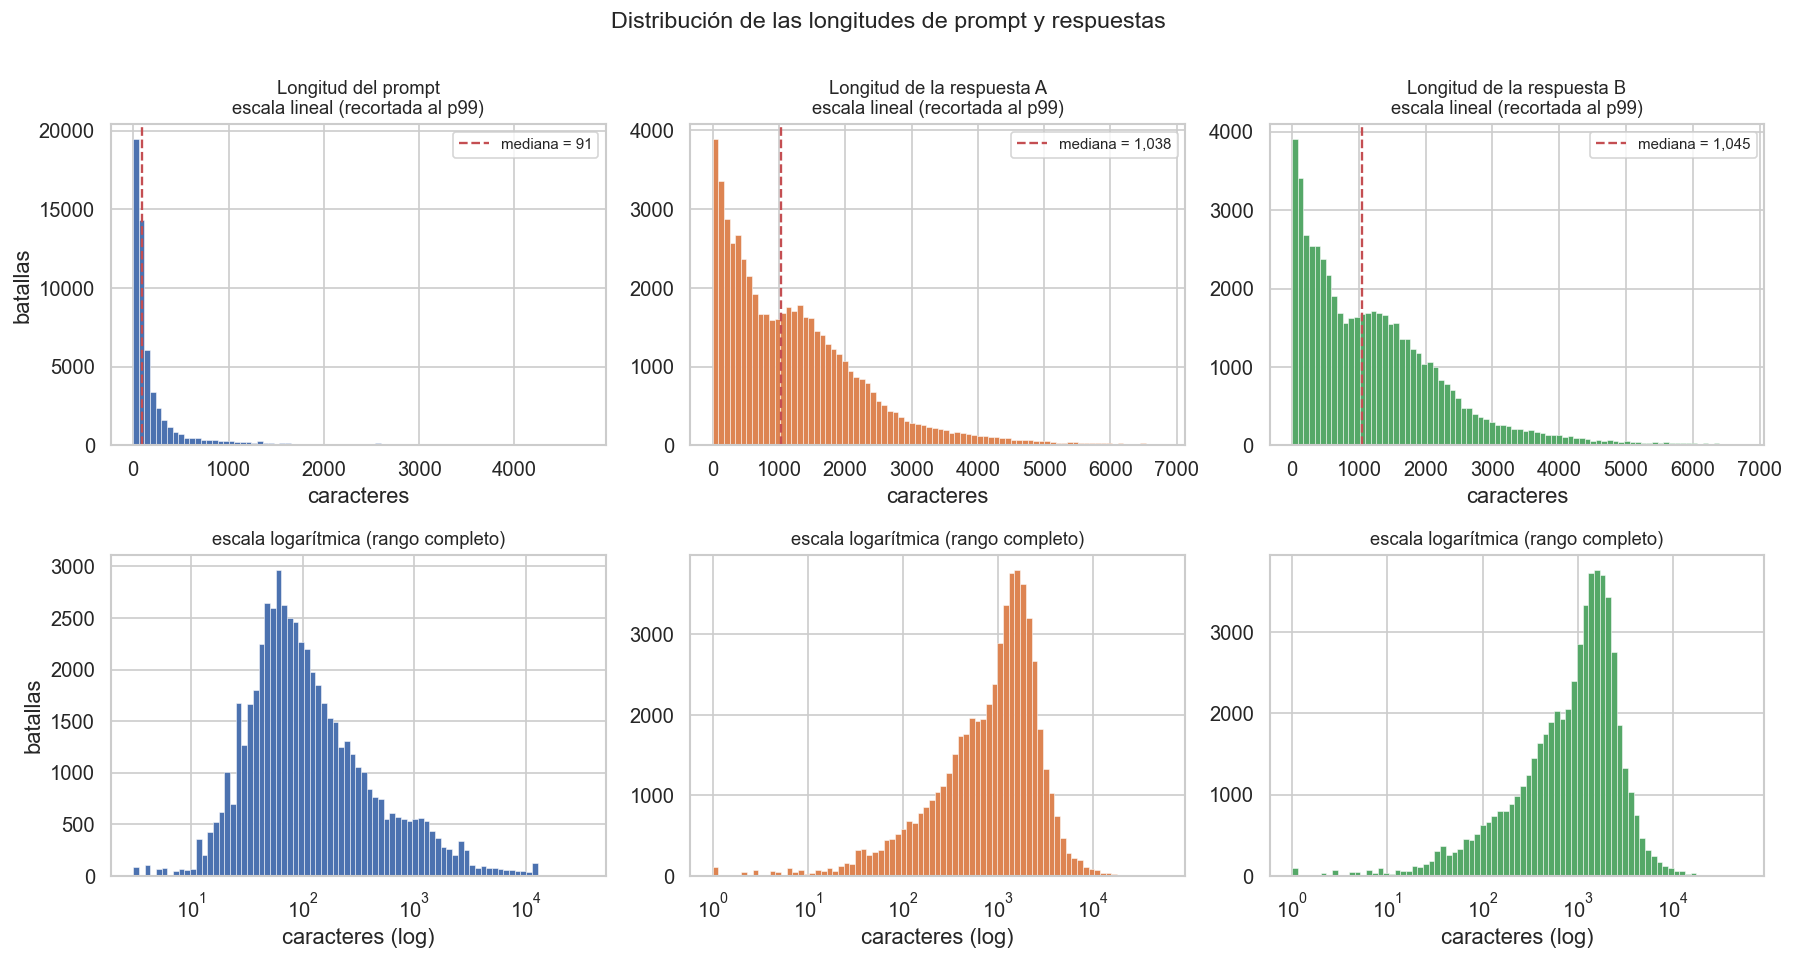

In [7]:
ETIQUETAS = {
    'prompt_len': 'Longitud del prompt',
    'resp_a_len': 'Longitud de la respuesta A',
    'resp_b_len': 'Longitud de la respuesta B',
}
COLORES = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, (col, color) in enumerate(zip(COLS_CARACTERES, COLORES)):
    datos = df[col]
    p99 = np.percentile(datos, 99)

    ax = axes[0, j]
    ax.hist(datos, bins=80, range=(0, p99), color=color, edgecolor='white', linewidth=.3)
    ax.set_title(f'{ETIQUETAS[col]}\nescala lineal (recortada al p99)', fontsize=11)
    ax.set_xlabel('caracteres')
    ax.set_ylabel('batallas' if j == 0 else '')
    ax.axvline(datos.median(), color='#C44E52', linestyle='--', linewidth=1.4,
               label=f'mediana = {datos.median():,.0f}')
    ax.legend(fontsize=9)

    ax = axes[1, j]
    positivos = datos[datos > 0]
    bins_log = np.logspace(np.log10(positivos.min()), np.log10(positivos.max()), 80)
    ax.hist(positivos, bins=bins_log, color=color, edgecolor='white', linewidth=.3)
    ax.set_xscale('log')
    ax.set_title('escala logarítmica (rango completo)', fontsize=11)
    ax.set_xlabel('caracteres (log)')
    ax.set_ylabel('batallas' if j == 0 else '')

fig.suptitle('Distribución de las longitudes de prompt y respuestas', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_hist_longitudes.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
comparacion = pd.DataFrame({
    'mediana': df[COLS_CARACTERES].median(),
    'p95': df[COLS_CARACTERES].quantile(.95),
    'p99': df[COLS_CARACTERES].quantile(.99),
    'máximo': df[COLS_CARACTERES].max(),
    'p99 / mediana': df[COLS_CARACTERES].quantile(.99) / df[COLS_CARACTERES].median(),
})
print(comparacion.round(1).to_string())

razon = df['resp_a_len'].median() / df['prompt_len'].median()
print(f'\nUna respuesta típica es {razon:.1f} veces más larga que el prompt que la origina.')

            mediana     p95     p99  máximo  p99 / mediana
prompt_len     91.0  1419.0  4720.3   32832           51.9
resp_a_len   1038.0  3587.0  6785.8   53299            6.5
resp_b_len   1045.0  3577.8  6736.9   52402            6.4

Una respuesta típica es 11.4 veces más larga que el prompt que la origina.


En escala lineal las tres variables se amontonan contra el eje izquierdo: mandan los prompts cortos y
las respuestas de extensión moderada. Al pasar a escala logarítmica la forma se vuelve
aproximadamente acampanada, que es lo típico de una distribución **log-normal** y lo que uno espera
al medir texto libre. Esto tiene una consecuencia práctica para modelar: conviene usar el logaritmo
de la longitud y no el valor crudo, para que unas pocas respuestas enormes dejen de dominar el ajuste.

Las distribuciones de A y B quedan casi superpuestas. Es lo esperable si los modelos se reparten
entre las dos posiciones al azar, y una primera señal de que ninguna posición sale favorecida por
cómo está armada la plataforma.

---
## 5. Número de Turnos

`n_turns` es la única variable cuantitativa discreta. Además de contar cuántas batallas hay en cada
nivel se mide la tasa de empate, para ver si conversar más turnos ayuda al usuario a decidirse.

In [9]:
tabla_turnos = pd.DataFrame({
    'batallas': df['n_turns'].value_counts().sort_index(),
    '% del total': (df['n_turns'].value_counts(normalize=True).sort_index() * 100).round(2),
    '% de empates': (df.groupby('n_turns', observed=True)['winner']
                       .apply(lambda s: (s == cfg.LABEL_MAP[cfg.COL_WIN_TIE]).mean() * 100).round(2)),
})
tabla_turnos.index.name = 'n_turns'
print(tabla_turnos.to_string())

multiturno = (df['n_turns'] > 1).mean() * 100
print(f'\nConversaciones de más de un turno: {multiturno:.2f}% de las batallas')

         batallas  % del total  % de empates
n_turns                                     
1           49868        86.87         31.26
2            4672         8.14         28.36
3            1485         2.59         28.69
4             607         1.06         26.52
5             311         0.54         26.37
6             167         0.29         28.14
7             103         0.18         27.18
8              60         0.10         28.33
9              44         0.08         22.73
10             29         0.05         20.69
11             16         0.03         31.25
12             14         0.02         42.86
13              5         0.01         20.00
14              3         0.01         33.33
15              4         0.01          0.00
16              2         0.00         50.00
17              3         0.01          0.00
18              1         0.00          0.00
19              4         0.01         50.00
20              2         0.00          0.00
21        

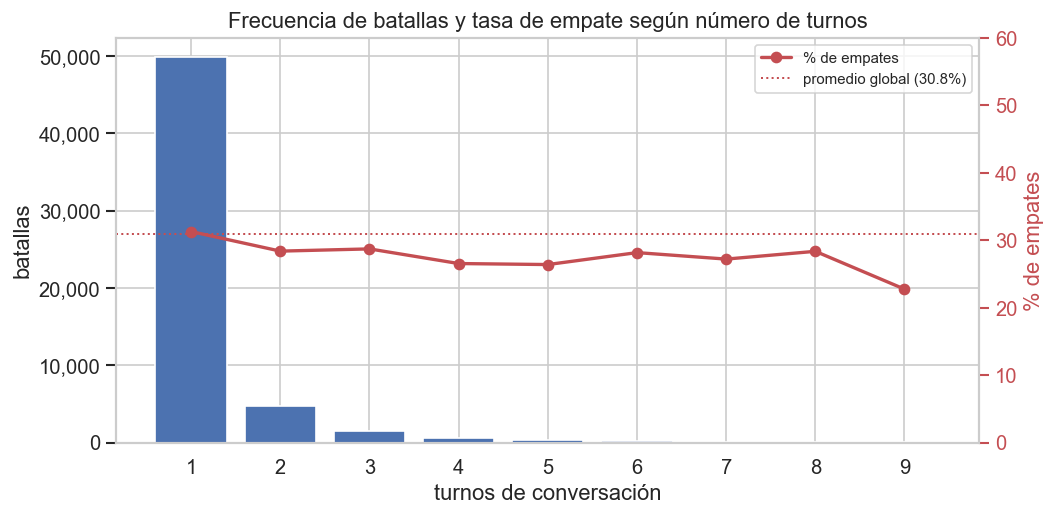

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
top_turnos = tabla_turnos[tabla_turnos['batallas'] >= 30]

ax.bar(top_turnos.index.astype(str), top_turnos['batallas'], color='#4C72B0', edgecolor='white')
ax.set_xlabel('turnos de conversación')
ax.set_ylabel('batallas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

tasa_global = (df['winner'] == cfg.LABEL_MAP[cfg.COL_WIN_TIE]).mean() * 100

ax2 = ax.twinx()
ax2.plot(top_turnos.index.astype(str), top_turnos['% de empates'],
         color='#C44E52', marker='o', linewidth=2, label='% de empates')
ax2.axhline(tasa_global, color='#C44E52', linestyle=':', linewidth=1.2,
            label=f'promedio global ({tasa_global:.1f}%)')
ax2.set_ylabel('% de empates', color='#C44E52')
ax2.tick_params(axis='y', colors='#C44E52')
# El eje se ancla en 0 para que la escala no magnifique diferencias de décimas.
ax2.set_ylim(0, max(60, top_turnos['% de empates'].max() * 1.3))
ax2.grid(False)
ax2.legend(loc='upper right', fontsize=9)

ax.set_title('Frecuencia de batallas y tasa de empate según número de turnos')
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_turnos.png', dpi=150, bbox_inches='tight')
plt.show()

Casi todas las batallas se resuelven en un solo intercambio y las conversaciones largas se vuelven
raras enseguida. El gráfico solo muestra los niveles con al menos 30 batallas, porque más allá de ahí
el porcentaje de empates se calcula sobre un puñado de casos y deja de ser confiable. La línea hay
que leerla junto con la altura de la barra que tiene debajo.

---
## 6. Longitud y Resultado

Los diagramas de caja van sin los valores atípicos, porque con una cola tan larga las cajas quedarían
comprimidas hasta no distinguirse entre sí. Los extremos se revisan aparte en la sección 7.

El panel izquierdo compara la extensión de cada respuesta según el resultado. El derecho usa
`dif_len`, la diferencia entre lo que escribió A y lo que escribió B: por encima de la línea de cero
escribió más A, por debajo escribió más B.

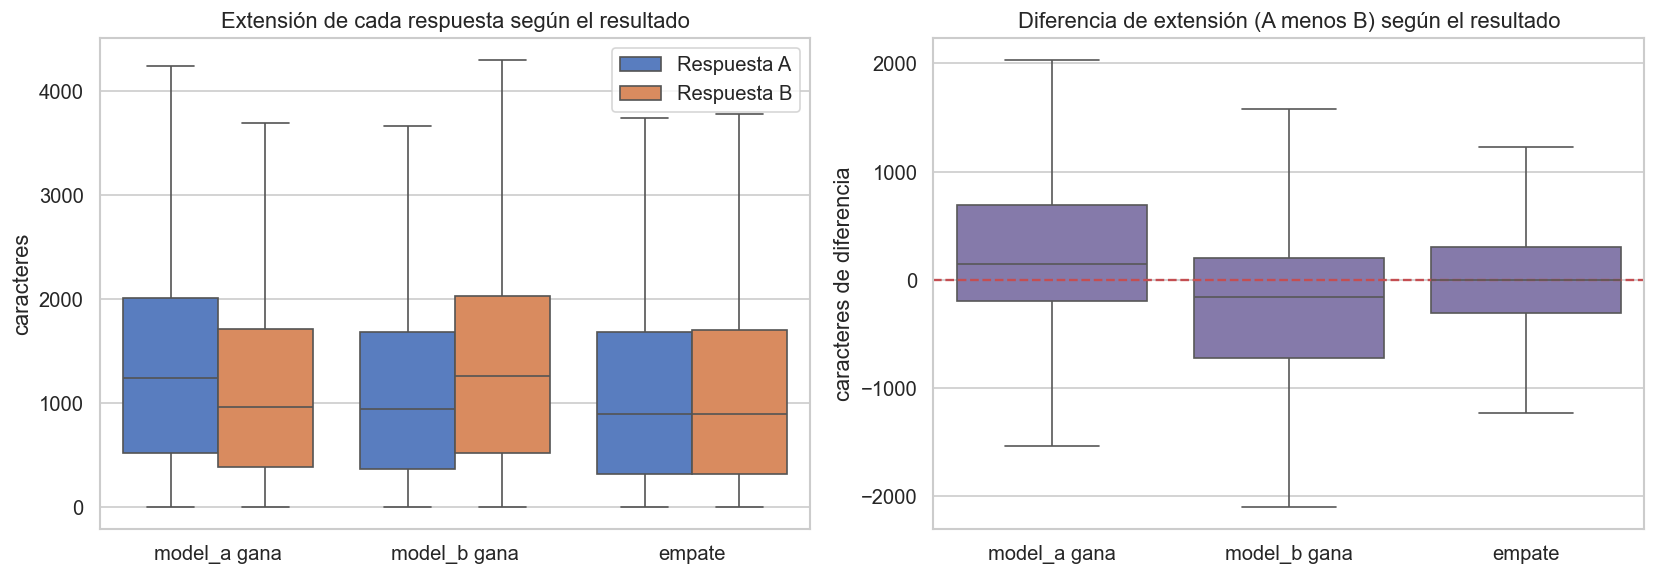

In [11]:
largos = pd.concat([
    df[['resultado', 'resp_a_len']].rename(columns={'resp_a_len': 'longitud'}).assign(respuesta='Respuesta A'),
    df[['resultado', 'resp_b_len']].rename(columns={'resp_b_len': 'longitud'}).assign(respuesta='Respuesta B'),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=largos, x='resultado', y='longitud', hue='respuesta',
            showfliers=False, ax=axes[0])
axes[0].set_title('Extensión de cada respuesta según el resultado')
axes[0].set_xlabel('')
axes[0].set_ylabel('caracteres')
axes[0].legend(title='')

sns.boxplot(data=df, x='resultado', y='dif_len', showfliers=False,
            color='#8172B2', ax=axes[1])
axes[1].axhline(0, color='#C44E52', linestyle='--', linewidth=1.4)
axes[1].set_title('Diferencia de extensión (A menos B) según el resultado')
axes[1].set_xlabel('')
axes[1].set_ylabel('caracteres de diferencia')

plt.tight_layout()
plt.savefig(FIGURAS / 'fig_boxplot_longitud_resultado.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
medianas = df.groupby('resultado', observed=True)[['resp_a_len', 'resp_b_len', 'dif_len']].median()
print('Medianas de longitud por resultado:')
print(medianas.round(1).to_string())

# Entre las batallas con ganador definido se compara la respuesta ganadora con la perdedora.
decisivas = df[df['winner'] != cfg.LABEL_MAP[cfg.COL_WIN_TIE]]
gana_a = decisivas['winner'] == cfg.LABEL_MAP[cfg.COL_WIN_A]
len_ganadora = np.where(gana_a, decisivas['resp_a_len'], decisivas['resp_b_len'])
len_perdedora = np.where(gana_a, decisivas['resp_b_len'], decisivas['resp_a_len'])

print(f'\nBatallas con ganador definido: {len(decisivas):,}')
print(f'  Mediana de la respuesta ganadora:  {np.median(len_ganadora):,.0f} caracteres')
print(f'  Mediana de la respuesta perdedora: {np.median(len_perdedora):,.0f} caracteres')

Medianas de longitud por resultado:
              resp_a_len  resp_b_len  dif_len
resultado                                    
model_a gana      1241.0       962.0    150.0
model_b gana       943.0      1259.0   -156.0
empate             894.5       893.0      0.0

Batallas con ganador definido: 39,698
  Mediana de la respuesta ganadora:  1,251 caracteres
  Mediana de la respuesta perdedora: 952 caracteres


In [13]:
# ¿Con qué frecuencia gana la respuesta más larga? Se excluyen los empates exactos de longitud.
mismo_largo = len_ganadora == len_perdedora
gano_la_mas_larga = (len_ganadora > len_perdedora)[~mismo_largo]
pct_larga = gano_la_mas_larga.mean() * 100

print(f'Batallas decisivas con longitudes distintas: {(~mismo_largo).sum():,}')
print(f'Ganó la respuesta más larga en el {pct_larga:.2f}% de los casos')
print(f'Desviación respecto al azar (50%): {pct_larga - 50:+.2f} puntos porcentuales')

# ¿Se declara el empate cuando ambas respuestas se parecen en extensión?
empates = df[df['winner'] == cfg.LABEL_MAP[cfg.COL_WIN_TIE]]
dif_empates = empates['dif_len'].abs().median()
dif_decisivas = decisivas['dif_len'].abs().median()

print(f'\nDiferencia absoluta de longitud entre ambas respuestas:')
print(f'  Mediana en batallas con empate:   {dif_empates:,.0f} caracteres')
print(f'  Mediana en batallas decisivas:    {dif_decisivas:,.0f} caracteres')
print(f'  Las decisivas superan a los empates en {(dif_decisivas / dif_empates - 1) * 100:+.1f}%')

Batallas decisivas con longitudes distintas: 39,597
Ganó la respuesta más larga en el 61.63% de los casos
Desviación respecto al azar (50%): +11.63 puntos porcentuales

Diferencia absoluta de longitud entre ambas respuestas:
  Mediana en batallas con empate:   307 caracteres
  Mediana en batallas decisivas:    463 caracteres
  Las decisivas superan a los empates en +50.8%


Si la longitud no influyera, la respuesta más larga ganaría la mitad de las veces. Todo lo que el
porcentaje se aleje de ese 50% es la magnitud del sesgo por verbosidad, medida directamente.

Ahora bien, es un sesgo y no una explicación completa: el porcentaje se despega del azar pero queda
lejos del 100%, así que la longitud pesa de verdad y aun así deja sin explicar la mayor parte del
voto.

La última comparación revisa una idea distinta sobre el empate: que el usuario lo declare justo
cuando las dos respuestas se parecen en extensión y no encuentra con qué separarlas. Si fuera así, la
diferencia absoluta de longitudes tendría que ser menor en los empates que en las batallas decisivas,
y el tamaño de esa brecha dice cuánto pesa ese mecanismo.

De acá salen dos cosas concretas. Para el modelado, `dif_len` es una variable que hay que incluir.
Para el negocio, un ranking de modelos que no controle por longitud va a premiar al más verboso en
lugar del más útil.

---
## 7. Valores Atípicos

Con distribuciones tan asimétricas, la regla clásica del rango intercuartílico marca como atípica una
cantidad enorme de observaciones y deja de servir. Se la compara con el criterio de percentil y, sobre
todo, se miran los casos extremos uno por uno para saber si son errores o datos legítimos.

In [14]:
resumen_outliers = []
for col in COLS_CARACTERES:
    q1, q3 = df[col].quantile([.25, .75])
    limite_iqr = q3 + 1.5 * (q3 - q1)
    p99 = df[col].quantile(.99)
    resumen_outliers.append({
        'variable': col,
        'límite IQR (q3 + 1.5·RIC)': round(limite_iqr, 1),
        'n sobre límite IQR': int((df[col] > limite_iqr).sum()),
        '% sobre límite IQR': round((df[col] > limite_iqr).mean() * 100, 2),
        'p99': round(p99, 1),
        'n sobre p99': int((df[col] > p99).sum()),
        'máximo': int(df[col].max()),
        'n en cero': int((df[col] == 0).sum()),
    })

pd.DataFrame(resumen_outliers).set_index('variable').T

variable,prompt_len,resp_a_len,resp_b_len
límite IQR (q3 + 1.5·RIC),512.00,3939.50,3954.50
n sobre límite IQR,7698.00,2220.00,2206.00
% sobre límite IQR,13.41,3.87,3.84
p99,4720.30,6785.80,6736.90
n sobre p99,575.00,575.00,575.00
máximo,32832.00,53299.00,52402.00
n en cero,0.00,31.00,33.00


In [15]:
# Cola superior: las respuestas más extensas del dataset.
df['resp_len_max'] = df[['resp_a_len', 'resp_b_len']].max(axis=1)
extremos = df.nlargest(5, 'resp_len_max')

for _, fila in extremos.iterrows():
    texto = fila['resp_a_text'] if fila['resp_a_len'] >= fila['resp_b_len'] else fila['resp_b_text']
    modelo = fila[cfg.COL_MODEL_A] if fila['resp_a_len'] >= fila['resp_b_len'] else fila[cfg.COL_MODEL_B]
    print(f'id {fila[cfg.COL_ID]} | {modelo} | {fila["resp_len_max"]:,} caracteres | '
          f'{fila["n_turns"]} turno(s) | resultado: {fila["resultado"]}')
    print(f'  inicio: {texto[:160].replace(chr(10), " ")}...')
    print()

id 2995198009 | gpt-4-0125-preview | 53,299 caracteres | 35 turno(s) | resultado: model_a gana
  inicio: You find yourself standing at the edge of the Whispering Woods, the sun setting behind the towering trees, casting long shadows across the path before you. The ...

id 3874210883 | claude-1 | 52,402 caracteres | 32 turno(s) | resultado: empate
  inicio: The correct answer is d. The release of pollutants into the soil, which can then enter groundwater.  Leaching refers to the process by which pollutants in the s...

id 2846599172 | gpt-4-1106-preview | 45,535 caracteres | 21 turno(s) | resultado: model_b gana
  inicio: Bees have a remarkable communication system known as the "waggle dance." When a forager bee finds a good source of nectar or pollen, she returns to the hive and...

id 2425787535 | claude-1 | 38,528 caracteres | 18 turno(s) | resultado: model_b gana
  inicio: Oh, that sounds like an interesting experience. A few possibilities here:  1. It could have been a dream. Our m

In [16]:
# Cola inferior: respuestas completamente vacías.
vacias = (df['resp_a_len'] == 0) | (df['resp_b_len'] == 0)
print(f'Batallas con al menos una respuesta vacía: {vacias.sum():,} ({vacias.mean() * 100:.3f}%)')

if vacias.any():
    resultado_vacias = df.loc[vacias, 'resultado'].value_counts(normalize=True).reindex(ORDEN_RESULTADO)
    resultado_global = df['resultado'].value_counts(normalize=True).reindex(ORDEN_RESULTADO)
    print()
    print(pd.DataFrame({
        '% con respuesta vacía': (resultado_vacias * 100).round(2),
        '% en el dataset completo': (resultado_global * 100).round(2),
    }).to_string())

Batallas con al menos una respuesta vacía: 45 (0.078%)

              % con respuesta vacía  % en el dataset completo
resultado                                                    
model_a gana                  33.33                     34.94
model_b gana                  31.11                     34.22
empate                        35.56                     30.85


**Decisión sobre los valores atípicos: se conservan.**

La regla del rango intercuartílico está mal calibrada para estos datos. Sobre una distribución normal
señala alrededor del 0.7% de las observaciones; acá marca un porcentaje varias veces mayor. No está
detectando anomalías, está detectando la cola normal de una log-normal, que es la forma que se vio en
la sección 4.

Al mirar los casos extremos aparecen respuestas reales y bien formadas: bloques de código largos,
tablas, enumeraciones, conversaciones de varios turnos acumulados. No hay errores de codificación ni
restos del parseo, es simplemente lo que hace un modelo cuando le piden algo que exige extenderse.
Borrarlos sería tirar justo el material que sostiene la hipótesis de verbosidad.

Las respuestas vacías tampoco son ruido. Son turnos que un modelo no contestó, y el usuario votó
viendo esa ausencia. Comparar cómo terminaron esas batallas contra el reparto general dice si
quedarse callado le cuesta caro al modelo, y eso es información, no un dato corrupto.

Para modelar, la salida no es borrar filas sino cambiar la escala: `log(1 + longitud)` o recortar por
el percentil 99 controlan el peso de la cola sin perder observaciones válidas.

---
## 8. Participación de los Modelos

`model_a` y `model_b` son la única variable categórica de cardinalidad alta del dataset. Interesan dos
cosas: cuántas batallas jugó cada modelo, porque de ahí depende con cuánta muestra se puede estimar
cualquier métrica suya, y qué tan parejo quedó el reparto entre la posición A y la B.

In [17]:
como_a = df[cfg.COL_MODEL_A].value_counts()
como_b = df[cfg.COL_MODEL_B].value_counts()

participacion = pd.DataFrame({'como_a': como_a, 'como_b': como_b}).fillna(0).astype(int)
participacion['apariciones'] = participacion['como_a'] + participacion['como_b']
participacion['% del total'] = (participacion['apariciones'] / participacion['apariciones'].sum() * 100).round(2)
participacion['% como A'] = (participacion['como_a'] / participacion['apariciones'] * 100).round(1)
participacion = participacion.sort_values('apariciones', ascending=False)

print(f'Modelos distintos: {len(participacion)}')
print(f'Apariciones totales: {participacion["apariciones"].sum():,} (2 por batalla)')
print()
print('Los 10 modelos más frecuentes:')
print(participacion.head(10).to_string())

Modelos distintos: 64
Apariciones totales: 114,812 (2 por batalla)

Los 10 modelos más frecuentes:
                            como_a  como_b  apariciones  % del total  % como A
gpt-4-1106-preview            3671    3708         7379         6.43      49.7
gpt-3.5-turbo-0613            3550    3525         7075         6.16      50.2
gpt-4-0613                    3094    3062         6156         5.36      50.3
claude-2.1                    2858    2722         5580         4.86      51.2
claude-instant-1              2077    2047         4124         3.59      50.4
gpt-4-0314                    2083    2030         4113         3.58      50.6
claude-1                      1951    2020         3971         3.46      49.1
vicuna-33b                    1842    1874         3716         3.24      49.6
mixtral-8x7b-instruct-v0.1    1741    1804         3545         3.09      49.1
vicuna-13b                    1701    1739         3440         3.00      49.4


In [18]:
concentracion = participacion['apariciones'].cumsum() / participacion['apariciones'].sum() * 100
print(f'Los 10 modelos más frecuentes concentran el {concentracion.iloc[9]:.1f}% de las apariciones')
print(f'La mitad superior de los modelos concentra el {concentracion.iloc[len(participacion) // 2 - 1]:.1f}%')
print()
print(f'Modelo con más apariciones: {participacion.index[0]} ({participacion["apariciones"].iloc[0]:,})')
print(f'Modelo con menos apariciones: {participacion.index[-1]} ({participacion["apariciones"].iloc[-1]:,})')
print(f'Razón entre ambos: {participacion["apariciones"].iloc[0] / participacion["apariciones"].iloc[-1]:.0f}x')
print()
print('Reparto entre posiciones A y B (esperado: 50% si la asignación es aleatoria):')
print(f'  Media entre modelos:  {participacion["% como A"].mean():.1f}%')
print(f'  Rango observado:      {participacion["% como A"].min():.1f}% a {participacion["% como A"].max():.1f}%')

# Con pocas apariciones el reparto se desvía por azar, así que se acota a los modelos con muestra suficiente.
frecuentes = participacion[participacion['apariciones'] >= 500]
print(f'  Rango en los {len(frecuentes)} modelos con 500+ apariciones: '
      f'{frecuentes["% como A"].min():.1f}% a {frecuentes["% como A"].max():.1f}%')

Los 10 modelos más frecuentes concentran el 42.8% de las apariciones
La mitad superior de los modelos concentra el 79.7%

Modelo con más apariciones: gpt-4-1106-preview (7,379)
Modelo con menos apariciones: mistral-7b-instruct-v0.2 (100)
Razón entre ambos: 74x

Reparto entre posiciones A y B (esperado: 50% si la asignación es aleatoria):
  Media entre modelos:  50.1%
  Rango observado:      44.3% a 54.1%
  Rango en los 55 modelos con 500+ apariciones: 47.7% a 54.1%


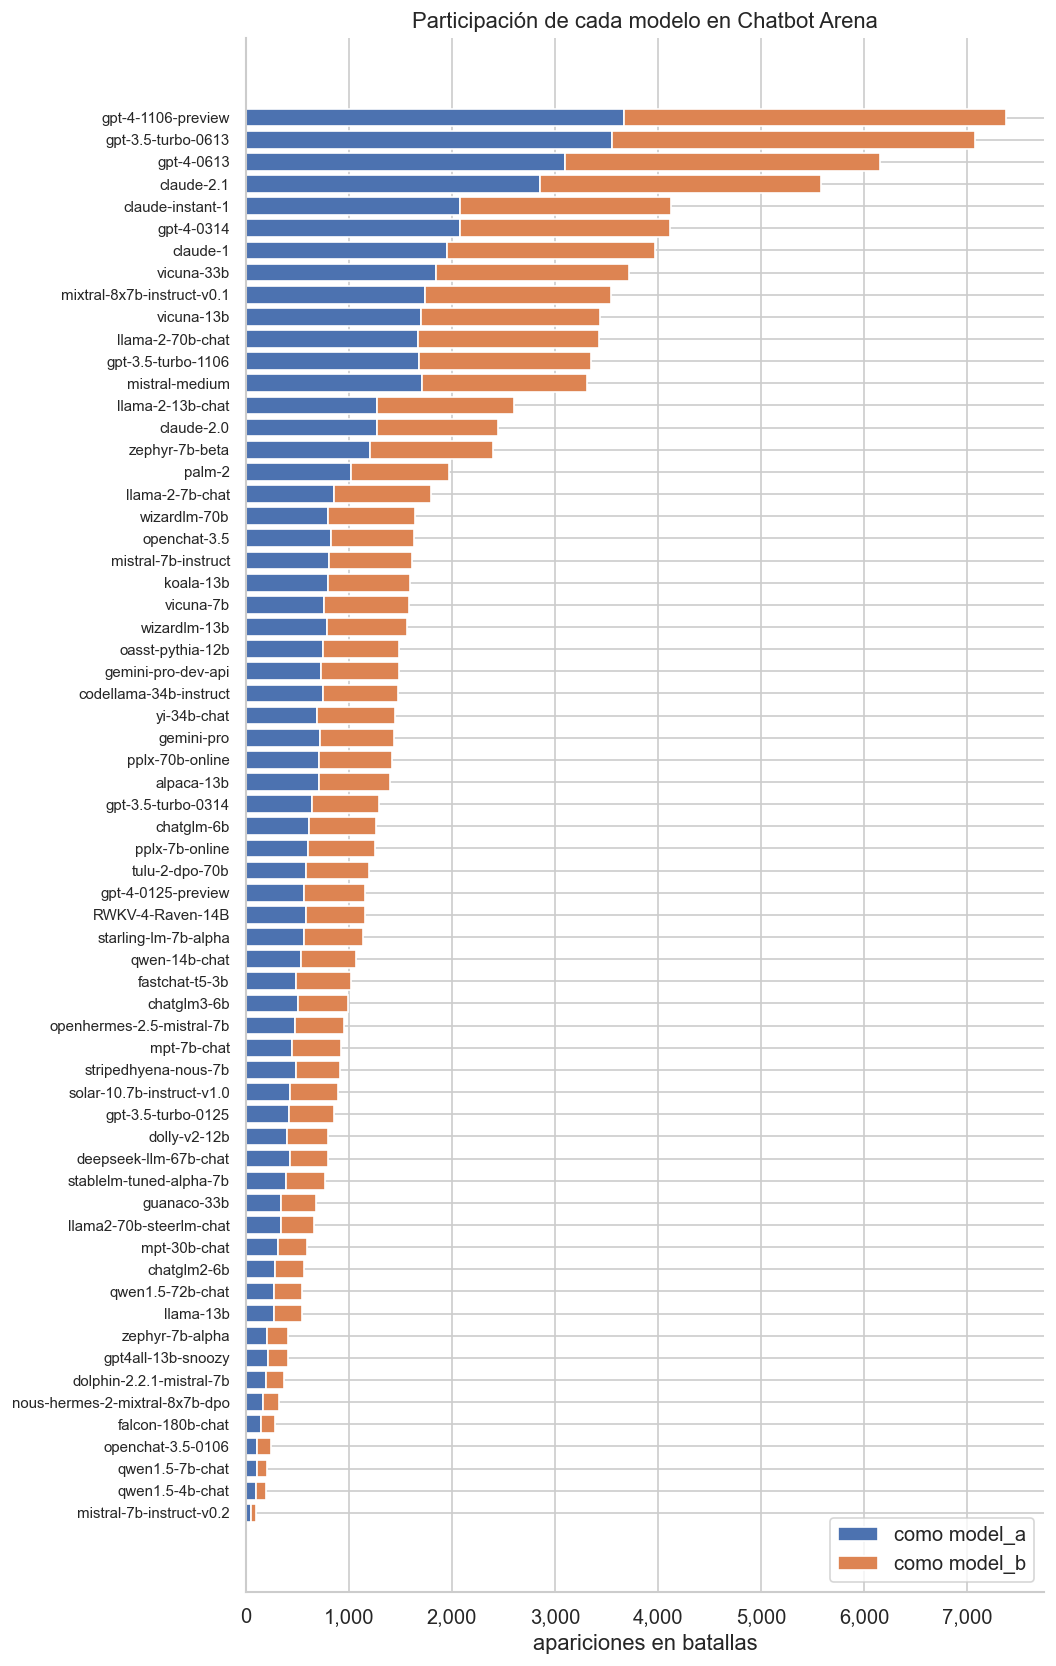

In [19]:
fig, ax = plt.subplots(figsize=(9, max(6, len(participacion) * 0.22)))
orden = participacion.sort_values('apariciones')

ax.barh(orden.index, orden['como_a'], color='#4C72B0', label='como model_a')
ax.barh(orden.index, orden['como_b'], left=orden['como_a'], color='#DD8452', label='como model_b')

ax.set_xlabel('apariciones en batallas')
ax.set_title('Participación de cada modelo en Chatbot Arena')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='y', labelsize=9)
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_participacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

La participación es muy despareja: unos pocos modelos concentran buena parte de las batallas y la
mayoría aparece apenas. Tiene sentido por cómo funciona la plataforma, donde los modelos populares se
enfrentan seguido y los que recién entraron o ya salieron dejan pocos registros. De acá sale una
advertencia para lo que venga: **una tasa de victoria no se puede comparar entre modelos sin mirar
cuántas batallas la respaldan**, porque un porcentaje sacado de unas decenas de casos y otro sacado de
miles no están en la misma liga.

El reparto entre A y B, en cambio, se queda cerca del 50% en los modelos con muestra suficiente. Eso
confirma que las posiciones se asignan al azar, que es justo lo que hace falta para poder atribuir
cualquier diferencia entre A y B al evaluador humano y no al diseño del experimento.

---
## 9. Hallazgos

**El dataset no traía variables numéricas.** Las siete que se analizaron acá salieron todas de medir
el texto durante la limpieza. Con el archivo original tal como viene, lo único que se podría hacer es
contar victorias por modelo.

**Las longitudes son log-normales, no normales.** La asimetría es alta, la media queda bastante por
encima de la mediana y el percentil 99 está varias veces arriba de ella. En escala logarítmica las
tres distribuciones se ven acampanadas. Cualquier técnica que asuma normalidad o que use la media sin
transformar va a dar resultados torcidos.

**El usuario escribe poco y recibe mucho.** El prompt mediano es varias veces más corto que la
respuesta que provoca. Como la extensión la decide el modelo y no la pregunta, la longitud de la
respuesta termina funcionando como un rasgo de estilo de cada modelo.

**Hay sesgo por verbosidad y está acotado.** Entre las batallas con ganador definido, la respuesta más
larga gana bastante más de la mitad de las veces, y la mediana de la ganadora supera a la de la
perdedora. El efecto es sistemático, pero queda lejos de explicar el voto por sí solo: la longitud
inclina la balanza, no la decide.

**El empate pesa demasiado como para tratarlo de ruido.** Es cerca de un tercio de las batallas, y en
ellas las dos respuestas se parecen más en extensión que en las batallas que sí tuvieron ganador.
Descartar los empates sería tirar un tercio de la información disponible.

**La participación de los modelos está muy concentrada.** Un puñado de modelos acumula la mayor parte
de las apariciones mientras que el reparto entre las posiciones A y B se mantiene equilibrado. Toda
métrica calculada por modelo tiene que ir acompañada del número de batallas que la respalda.

Con esto queda listo el terreno para el análisis de las variables categóricas. La longitud ya está
identificada y medida como factor de confusión, así que las diferencias entre modelos hay que leerlas
sabiendo cuánto escribe cada uno y sobre cuántas batallas se calculó su desempeño.